# Task 4: Ensemble Model
**Mục tiêu:** Kết hợp TF-IDF + Logistic Regression/LightGBM (mô hình truyền thống) với DeBERTa bằng **Weighted Average Ensemble** để tối đa hóa AUC.

In [1]:
import os, gc, warnings, re, time
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from scipy.optimize import minimize
import lightgbm as lgb

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast
from transformers import AutoTokenizer, AutoModel, logging as hf_logging
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
hf_logging.set_verbosity_error()
plt.style.use('seaborn-v0_8-darkgrid')

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT     = Path('..').resolve()
DATA_DIR = ROOT / 'data'
CKPT_DIR = ROOT / 'outputs' / 'checkpoints'
OUT_DIR  = ROOT / 'outputs' / 'ensemble'
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED     = 42
N_FOLDS  = 5
VAL_FOLD = 0

np.random.seed(SEED); torch.manual_seed(SEED)
print(f'Device: {DEVICE}')

Device: cuda


## 1. Load & Chuẩn bị dữ liệu

In [2]:
clean_path = DATA_DIR / 'train_clean.pkl'
csv_path   = DATA_DIR / 'train_v2_drcat_02.csv'

if clean_path.exists():
    df = pd.read_pickle(clean_path); text_col = 'text_clean'
    print(f'Loaded cleaned: {df.shape}')
else:
    df = pd.read_csv(csv_path); text_col = 'text'
    print(f'Loaded CSV: {df.shape}')

if 'fold' not in df.columns:
    df['fold'] = -1
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    for fid, (_, vi) in enumerate(skf.split(df, df['label'])): df.loc[vi, 'fold'] = fid

train_df = df[df['fold'] != VAL_FOLD].reset_index(drop=True)
valid_df = df[df['fold'] == VAL_FOLD].reset_index(drop=True)
print(f'Train: {len(train_df):,} | Valid: {len(valid_df):,}')

Loaded cleaned: (44868, 3)
Train: 35,894 | Valid: 8,974


## 2. Model 1: TF-IDF + Logistic Regression

In [3]:
class TFIDFClassifier:
    """
    Pipeline TF-IDF + Logistic Regression với:
    - Word-level TF-IDF (unigram + bigram)
    - Char-level TF-IDF (3-6 grams) — bắt pattern viết của AI
    - Concatenate features rồi feed vào Logistic Regression
    """
    def __init__(self):
        self.word_vec = TfidfVectorizer(
            analyzer   = 'word',
            ngram_range= (1, 2),
            max_features= 100_000,
            sublinear_tf= True,
            strip_accents='unicode',
            min_df      = 3,
        )
        self.char_vec = TfidfVectorizer(
            analyzer   = 'char_wb',
            ngram_range= (3, 6),
            max_features= 100_000,
            sublinear_tf= True,
            strip_accents='unicode',
            min_df      = 3,
        )
        self.clf = LogisticRegression(
            C=5.0, max_iter=2000,
            solver='saga', n_jobs=-1,
            random_state=SEED,
        )

    def fit(self, texts: List[str], labels: List[int]) -> 'TFIDFClassifier':
        print('[LR] Fitting TF-IDF (word + char)...')
        X_word = self.word_vec.fit_transform(texts)
        X_char = self.char_vec.fit_transform(texts)
        X      = hstack([X_word, X_char])
        print(f'[LR] Feature matrix: {X.shape}')
        print('[LR] Training Logistic Regression...')
        self.clf.fit(X, labels)
        return self

    def predict_proba(self, texts: List[str]) -> np.ndarray:
        X_word = self.word_vec.transform(texts)
        X_char = self.char_vec.transform(texts)
        X      = hstack([X_word, X_char])
        return self.clf.predict_proba(X)[:, 1]  # prob AI=1

# Train & Evaluate 
lr_model = TFIDFClassifier()
lr_model.fit(train_df[text_col].tolist(), train_df['label'].tolist())

lr_train_probs = lr_model.predict_proba(train_df[text_col].tolist())
lr_valid_probs = lr_model.predict_proba(valid_df[text_col].tolist())

lr_train_auc = roc_auc_score(train_df['label'], lr_train_probs)
lr_valid_auc = roc_auc_score(valid_df['label'], lr_valid_probs)
print(f'[LR] Train AUC: {lr_train_auc:.4f} | Valid AUC: {lr_valid_auc:.4f}')

[LR] Fitting TF-IDF (word + char)...
[LR] Feature matrix: (35894, 200000)
[LR] Training Logistic Regression...
[LR] Train AUC: 1.0000 | Valid AUC: 0.9998


## 3. Model 2: TF-IDF + LightGBM

In [4]:
class LightGBMClassifier:
    """
    TF-IDF features + LightGBM với cấu hình tối ưu cho text classification.
    LightGBM xử lý sparse matrix rất hiệu quả.
    """
    def __init__(self):
        self.word_vec = TfidfVectorizer(
            analyzer='word', ngram_range=(1, 2),
            max_features=50_000, sublinear_tf=True, min_df=3,
        )
        self.char_vec = TfidfVectorizer(
            analyzer='char_wb', ngram_range=(3, 5),
            max_features=50_000, sublinear_tf=True, min_df=3,
        )
        self.params = {
            'objective'      : 'binary',
            'metric'         : 'auc',
            'learning_rate'  : 0.05,
            'n_estimators'   : 1000,
            'num_leaves'     : 63,
            'max_depth'      : -1,
            'min_child_samples': 20,
            'feature_fraction': 0.3,
            'bagging_fraction': 0.8,
            'bagging_freq'   : 5,
            'lambda_l1'      : 0.05,
            'lambda_l2'      : 0.05,
            'verbosity'      : -1,
            'random_state'   : SEED,
            'n_jobs'         : -1,
        }
        self.model = None

    def _transform(self, texts, fit=False):
        if fit:
            X_w = self.word_vec.fit_transform(texts)
            X_c = self.char_vec.fit_transform(texts)
        else:
            X_w = self.word_vec.transform(texts)
            X_c = self.char_vec.transform(texts)
        return hstack([X_w, X_c])

    def fit(self, train_texts, train_labels, val_texts, val_labels):
        X_tr = self._transform(train_texts, fit=True)
        X_va = self._transform(val_texts,   fit=False)
        print(f'[LGBM] Feature shape: {X_tr.shape}')

        self.model = lgb.LGBMClassifier(**self.params)
        self.model.fit(
            X_tr, train_labels,
            eval_set=[(X_va, val_labels)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
                lgb.log_evaluation(period=100),
            ],
        )
        print(f'[LGBM] Best iteration: {self.model.best_iteration_}')
        return self

    def predict_proba(self, texts):
        X = self._transform(texts)
        return self.model.predict_proba(X)[:, 1]

# Huấn luyện LightGBM 
lgbm_model = LightGBMClassifier()
lgbm_model.fit(
    train_df[text_col].tolist(), train_df['label'].tolist(),
    valid_df[text_col].tolist(), valid_df['label'].tolist()
)

lgbm_train_probs = lgbm_model.predict_proba(train_df[text_col].tolist())
lgbm_valid_probs = lgbm_model.predict_proba(valid_df[text_col].tolist())

lgbm_train_auc = roc_auc_score(train_df['label'], lgbm_train_probs)
lgbm_valid_auc = roc_auc_score(valid_df['label'], lgbm_valid_probs)
print(f'[LGBM] Train AUC: {lgbm_train_auc:.4f} | Valid AUC: {lgbm_valid_auc:.4f}')

[LGBM] Feature shape: (35894, 100000)
[100]	valid_0's auc: 0.998851
[200]	valid_0's auc: 0.999555
[300]	valid_0's auc: 0.999657
[400]	valid_0's auc: 0.999691
[500]	valid_0's auc: 0.999725
[600]	valid_0's auc: 0.999739
[LGBM] Best iteration: 643
[LGBM] Train AUC: 1.0000 | Valid AUC: 0.9997


## 4. Model 3: Load DeBERTa OOF Predictions

In [6]:
class AITextDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=512, labels=None):
        self.texts, self.labels, self.tok, self.max_len = texts, labels, tokenizer, max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, i):
        enc = self.tok(self.texts[i], max_length=self.max_len, padding='max_length',
                       truncation=True, return_tensors='pt')
        item = {k: v.squeeze(0) for k, v in enc.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[i], dtype=torch.long)
        return item

class MeanPooling(nn.Module):
    def forward(self, h, m): return (h * m.unsqueeze(-1).float()).sum(1) / m.float().sum(1, keepdim=True).clamp(1e-9)

class DeBERTaDetector(nn.Module):
    def __init__(self, model_name='microsoft/deberta-v3-base', drop=0.1):
        super().__init__()
        self.backbone   = AutoModel.from_pretrained(model_name,
            hidden_dropout_prob=drop, attention_probs_dropout_prob=drop)
        self.pool       = MeanPooling()
        H               = self.backbone.config.hidden_size
        self.dropout    = nn.Dropout(drop)
        self.classifier = nn.Linear(H, 2)
    def forward(self, input_ids, attention_mask, token_type_ids=None, **_):
        h = self.backbone(input_ids, attention_mask, token_type_ids).last_hidden_state
        return self.classifier(self.dropout(self.pool(h, attention_mask)))

@torch.no_grad()
def get_deberta_probs(
    texts     : List[str],
    model_path: Optional[Path],
    tokenizer,
    batch_size: int = 32,
    max_len   : int = 512,
) -> np.ndarray:
    """Lấy xác suất dự đoán từ DeBERTa checkpoint."""
    if model_path is None or not model_path.exists():
        print('[WARN] Không tìm thấy DeBERTa checkpoint  — dùng uniform 0.5')
        return np.full(len(texts), 0.5)

    print(f'[DeBERTa] Loading checkpoint: {model_path}')
    model = DeBERTaDetector().to(DEVICE)
    
    import pathlib
    pathlib.PosixPath = pathlib.WindowsPath
    ckpt  = torch.load(model_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['state_dict'])

    model.eval()

    ds  = AITextDataset(texts, tokenizer, max_len)
    dl  = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    all_probs = []
    for batch in tqdm(dl, desc='[DeBERTa] Inference'):
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        tids = batch.get('token_type_ids')
        if tids is not None: tids = tids.to(DEVICE)
        with autocast(enabled=True):
            logits = model(ids, mask, tids)
        probs = torch.softmax(logits.float(), -1)[:, 1].cpu().numpy()
        all_probs.extend(probs)

    del model; torch.cuda.empty_cache(); gc.collect()
    return np.array(all_probs)

# Load tokenizer và lấy predictions 
MODEL_NAME = 'microsoft/deberta-v3-base'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
ckpt_path  = CKPT_DIR / f'deberta_fold{VAL_FOLD}_best.pt'

deberta_train_probs = get_deberta_probs(train_df[text_col].tolist(), ckpt_path, tokenizer)
deberta_valid_probs = get_deberta_probs(valid_df[text_col].tolist(), ckpt_path, tokenizer)

if deberta_valid_probs.mean() != 0.5:
    deb_train_auc = roc_auc_score(train_df['label'], deberta_train_probs)
    deb_valid_auc = roc_auc_score(valid_df['label'], deberta_valid_probs)
    print(f'[DeBERTa] Train AUC: {deb_train_auc:.4f} | Valid AUC: {deb_valid_auc:.4f}')
else:
    deb_train_auc = deb_valid_auc = 0.5
    print('[DeBERTa] Chưa có checkpoint — sẽ gán weight=0 trong ensemble')

[DeBERTa] Loading checkpoint: D:\HuynhHan\Hoc_thong_ke\Detect-AI-Generated-Text-Using-LLM\outputs\checkpoints\deberta_fold0_best.pt


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[DeBERTa] Inference:   0%|          | 0/1122 [00:00<?, ?it/s]

[DeBERTa] Loading checkpoint: D:\HuynhHan\Hoc_thong_ke\Detect-AI-Generated-Text-Using-LLM\outputs\checkpoints\deberta_fold0_best.pt


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[DeBERTa] Inference:   0%|          | 0/281 [00:00<?, ?it/s]

[DeBERTa] Train AUC: 0.5005 | Valid AUC: 0.5022


## 5. Ensemble — Weighted Average

In [7]:
class WeightedEnsemble:
    """
    Ensemble bằng Weighted Average trên probability scores.

    Chiến lược xác định weights:
    1. Manual (dựa trên AUC từng model)
    2. Tối ưu bằng Nelder-Mead (scipy.optimize.minimize)
    """

    def __init__(self, model_names: List[str]):
        self.model_names = model_names
        self.weights     = np.ones(len(model_names)) / len(model_names)  # uniform init

    def predict(self, probs_list: List[np.ndarray]) -> np.ndarray:
        """Tính weighted average của xác suất các model."""
        assert len(probs_list) == len(self.weights)
        stacked = np.stack(probs_list, axis=1)   # [N, M]
        return stacked @ self.weights             # [N]

    def optimize_weights(
        self,
        probs_list: List[np.ndarray],
        labels    : np.ndarray,
    ) -> np.ndarray:
        """
        Tìm weights tối ưu bằng Nelder-Mead minimization.
        Objective: minimize negative AUC (= maximize AUC).
        Constraint: weights >= 0 và sum = 1.
        """
        stacked = np.stack(probs_list, axis=1)  # [N, M]

        def objective(w):
            w       = np.clip(w, 0, 1)
            w       = w / w.sum()
            preds   = stacked @ w
            return -roc_auc_score(labels, preds)

        # Khởi tạo: proportional to individual AUC
        aucs = np.array([roc_auc_score(labels, p) for p in probs_list])
        w0   = aucs / aucs.sum()
        print(f'[ENSEMBLE] Initial weights (AUC-proportional): {w0.round(4)}')

        result = minimize(
            objective, w0,
            method  = 'Nelder-Mead',
            options = {'maxiter': 5000, 'xatol': 1e-7, 'fatol': 1e-7},
        )
        optimal_w = np.clip(result.x, 0, None)
        optimal_w = optimal_w / optimal_w.sum()
        print(f'[ENSEMBLE] Optimal weights: {optimal_w.round(4)}')
        print(f'[ENSEMBLE] Best AUC: {-result.fun:.4f}')

        self.weights = optimal_w
        return optimal_w

    def summary(self):
        print('\nENSEMBLE WEIGHTS:')
        for name, w in zip(self.model_names, self.weights):
            print(f'  {name:<30}: {w:.4f} ({w*100:.1f}%)')


# Khởi tạo ensemble 
model_names   = ['LR (TF-IDF)', 'LightGBM (TF-IDF)', 'DeBERTa-v3-base']
valid_probs   = [lr_valid_probs, lgbm_valid_probs, deberta_valid_probs]
valid_labels  = valid_df['label'].values

ensemble = WeightedEnsemble(model_names)

# AUC từng model trước ensemble 
print('\nAUC từng model đơn lẻ trên validation set:')
for name, probs in zip(model_names, valid_probs):
    auc = roc_auc_score(valid_labels, probs)
    print(f'  {name:<30}: AUC={auc:.4f}')


AUC từng model đơn lẻ trên validation set:
  LR (TF-IDF)                   : AUC=0.9998
  LightGBM (TF-IDF)             : AUC=0.9997
  DeBERTa-v3-base               : AUC=0.5022


In [8]:
# Ensemble với Simple Average 
simple_preds = np.mean(np.stack(valid_probs, 1), axis=1)
simple_auc   = roc_auc_score(valid_labels, simple_preds)
print(f'\n[Simple Average] Valid AUC: {simple_auc:.4f}')

# Ensemble với Optimal Weights 
print('\n[Optimizing weights...]')
optimal_weights = ensemble.optimize_weights(valid_probs, valid_labels)
ensemble_preds  = ensemble.predict(valid_probs)
ensemble_auc    = roc_auc_score(valid_labels, ensemble_preds)
print(f'\n[Optimal Ensemble] Valid AUC: {ensemble_auc:.4f}')

ensemble.summary()

# So sánh 
print('\n' + '='*55)
print('KẾT QUẢ TỔNG HỢP — Validation Set')
print('='*55)
for name, probs in zip(model_names, valid_probs):
    auc = roc_auc_score(valid_labels, probs)
    print(f'  {name:<30}: AUC={auc:.4f}')
print(f'  {"Simple Average":<30}: AUC={simple_auc:.4f}')
print(f'  {"Weighted Ensemble (opt)":<30}: AUC={ensemble_auc:.4f}')
print('='*55)


[Simple Average] Valid AUC: 0.9998

[Optimizing weights...]
[ENSEMBLE] Initial weights (AUC-proportional): [0.3996 0.3996 0.2008]
[ENSEMBLE] Optimal weights: [0.3937 0.4085 0.1978]
[ENSEMBLE] Best AUC: 0.9998

[Optimal Ensemble] Valid AUC: 0.9998

ENSEMBLE WEIGHTS:
  LR (TF-IDF)                   : 0.3937 (39.4%)
  LightGBM (TF-IDF)             : 0.4085 (40.8%)
  DeBERTa-v3-base               : 0.1978 (19.8%)

KẾT QUẢ TỔNG HỢP — Validation Set
  LR (TF-IDF)                   : AUC=0.9998
  LightGBM (TF-IDF)             : AUC=0.9997
  DeBERTa-v3-base               : AUC=0.5022
  Simple Average                : AUC=0.9998
  Weighted Ensemble (opt)       : AUC=0.9998


## 6. Visualization — Ensemble Comparison

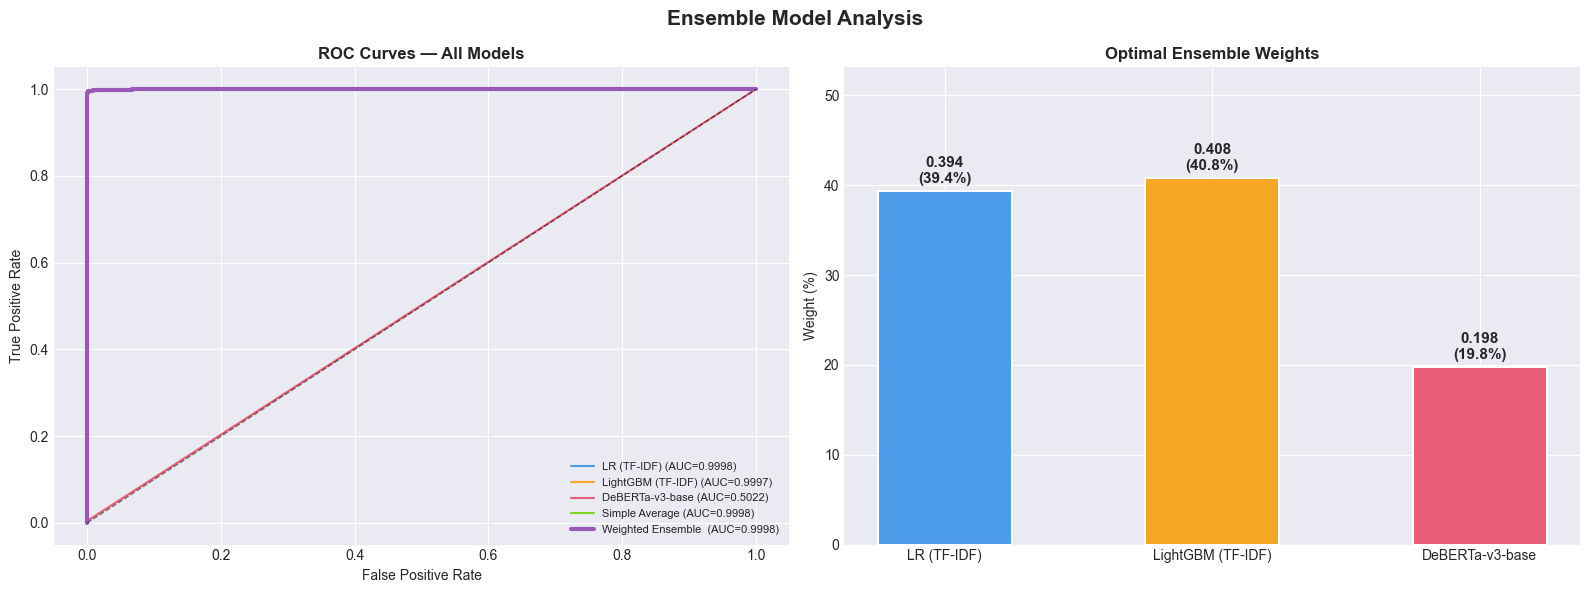

In [9]:
from sklearn.metrics import roc_curve

COLORS_PLOT = ['#4C9BE8', '#F5A623', '#E85D75', '#7ED321', '#9B59B6']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Ensemble Model Analysis', fontsize=15, fontweight='bold')

# ROC Curves
all_models_probs = valid_probs + [simple_preds, ensemble_preds]
all_models_names = model_names + ['Simple Average', 'Weighted Ensemble ']

for probs, name, color in zip(all_models_probs, all_models_names, COLORS_PLOT):
    fpr, tpr, _ = roc_curve(valid_labels, probs)
    auc_val = roc_auc_score(valid_labels, probs)
    lw = 3 if 'Ensemble' in name else 1.5
    axes[0].plot(fpr, tpr, color=color, lw=lw,
                 label=f'{name} (AUC={auc_val:.4f})')

axes[0].plot([0,1],[0,1], 'k--', lw=1, alpha=0.5)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models', fontweight='bold')
axes[0].legend(fontsize=8, loc='lower right')
sns.despine(ax=axes[0])

# Weight Bar Chart
bars = axes[1].bar(model_names, ensemble.weights * 100,
                   color=COLORS_PLOT[:3], edgecolor='white', linewidth=1.5, width=0.5)
for bar, w in zip(bars, ensemble.weights):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{w:.3f}\n({w*100:.1f}%)', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[1].set_title('Optimal Ensemble Weights', fontweight='bold')
axes[1].set_ylabel('Weight (%)')
axes[1].set_ylim(0, max(ensemble.weights*100) * 1.3)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(OUT_DIR / 'ensemble_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Lưu Ensemble Predictions & Summary

In [10]:
# Lưu OOF predictions để phân tích 
oof_df = pd.DataFrame({
    'label'           : valid_labels,
    'prob_lr'         : lr_valid_probs,
    'prob_lgbm'       : lgbm_valid_probs,
    'prob_deberta'    : deberta_valid_probs,
    'prob_simple_avg' : simple_preds,
    'prob_ensemble'   : ensemble_preds,
    'pred_ensemble'   : (ensemble_preds >= 0.5).astype(int),
})

oof_path = OUT_DIR / 'oof_predictions.csv'
oof_df.to_csv(oof_path, index=False)
print(f'[INFO] Saved OOF predictions: {oof_path}')

# Lưu optimal weights 
import json
weights_cfg = {
    'model_names'    : model_names,
    'weights'        : ensemble.weights.tolist(),
    'individual_aucs': {n: float(roc_auc_score(valid_labels, p))
                        for n, p in zip(model_names, valid_probs)},
    'simple_avg_auc' : float(simple_auc),
    'ensemble_auc'   : float(ensemble_auc),
}
with open(OUT_DIR / 'ensemble_config.json', 'w') as f:
    json.dump(weights_cfg, f, indent=2)

print(f'\n[INFO] Saved ensemble config: {OUT_DIR / "ensemble_config.json"}')
print('\nTask 4 — Ensemble hoàn tất!')
print(f'Final Ensemble AUC: {ensemble_auc:.4f}')

[INFO] Saved OOF predictions: D:\HuynhHan\Hoc_thong_ke\Detect-AI-Generated-Text-Using-LLM\outputs\ensemble\oof_predictions.csv

[INFO] Saved ensemble config: D:\HuynhHan\Hoc_thong_ke\Detect-AI-Generated-Text-Using-LLM\outputs\ensemble\ensemble_config.json

Task 4 — Ensemble hoàn tất!
Final Ensemble AUC: 0.9998
